# Part 2 — Taxi-v3

### Environment Setup
Run the following in your terminal:
```
conda activate rl-bandits
```

### Imports

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

# Device selection
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.10.0
Device: mps


### Environment Exploration

In [30]:
env = gym.make('Taxi-v3', render_mode='ansi')

print(f"Observation Space: {env.observation_space}")
print(f"  Type: {type(env.observation_space).__name__}")
print(f"  n (number of states): {env.observation_space.n}")
print()
print(f"Action Space: {env.action_space}")
print(f"  Type: {type(env.action_space).__name__}")
print(f"  n (number of actions): {env.action_space.n}")
print(f"  Actions: 0=South, 1=North, 2=East, 3=West, 4=Pickup, 5=Dropoff")
print()

obs, info = env.reset(seed=42)
print(f"Initial observation: {obs}")
print(f"Info: {info}")

Observation Space: Discrete(500)
  Type: Discrete
  n (number of states): 500

Action Space: Discrete(6)
  Type: Discrete
  n (number of actions): 6
  Actions: 0=South, 1=North, 2=East, 3=West, 4=Pickup, 5=Dropoff

Initial observation: 386
Info: {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)}


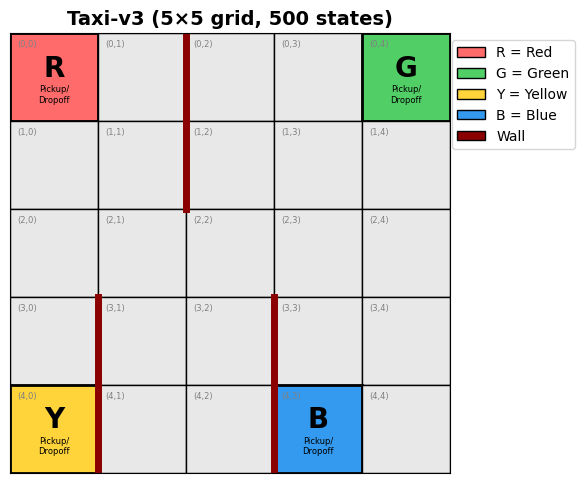

In [31]:
# Visualize the Taxi grid
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(6, 6))
nrow, ncol = 5, 5

# Color-coded grid: pickup/dropoff locations get colors, rest are light gray
locations = {'R': (0, 0), 'G': (0, 4), 'Y': (4, 0), 'B': (4, 3)}
loc_colors = {'R': '#FF6B6B', 'G': '#51CF66', 'Y': '#FFD43B', 'B': '#339AF0'}

# Build a lookup from (row, col) -> location name
loc_lookup = {pos: name for name, pos in locations.items()}

for i in range(nrow):
    for j in range(ncol):
        y = nrow - 1 - i
        if (i, j) in loc_lookup:
            name = loc_lookup[(i, j)]
            color = loc_colors[name]
            ax.add_patch(plt.Rectangle((j, y), 1, 1, facecolor=color, edgecolor='black', linewidth=2))
            ax.text(j + 0.5, y + 0.6, name, ha='center', va='center',
                    fontsize=20, fontweight='bold', color='black')
            ax.text(j + 0.5, y + 0.3, 'Pickup/\nDropoff', ha='center', va='center',
                    fontsize=6, color='black')
        else:
            ax.add_patch(plt.Rectangle((j, y), 1, 1, facecolor='#E8E8E8', edgecolor='black', linewidth=1))

        # Grid coordinate
        ax.text(j + 0.08, y + 0.92, f'({i},{j})', ha='left', va='top', fontsize=6, color='gray')

# Walls between cells
walls = [
    (0, 1, 0, 2), (1, 1, 1, 2),   # between col 1-2, rows 0-1
    (3, 0, 3, 1), (4, 0, 4, 1),   # between col 0-1, rows 3-4
    (3, 2, 3, 3), (4, 2, 4, 3),   # between col 2-3, rows 3-4
]
for r1, c1, r2, c2 in walls:
    x = max(c1, c2)
    y = nrow - 1 - r1
    ax.plot([x, x], [y, y + 1], color='#8B0000', linewidth=5)

ax.set_xlim(0, ncol)
ax.set_ylim(0, nrow)
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Taxi-v3 (5×5 grid, 500 states)', fontsize=14, fontweight='bold')

legend_elements = [
    Patch(facecolor=loc_colors['R'], edgecolor='black', label='R = Red'),
    Patch(facecolor=loc_colors['G'], edgecolor='black', label='G = Green'),
    Patch(facecolor=loc_colors['Y'], edgecolor='black', label='Y = Yellow'),
    Patch(facecolor=loc_colors['B'], edgecolor='black', label='B = Blue'),
    Patch(facecolor='#8B0000', edgecolor='black', label='Wall'),
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()

### MDP Mapping

| MDP Component | Mathematical Notation | Taxi-v3 Gymnasium Mapping |
|---|---|---|
| **States (S)** | $S \in \{0, 1, ..., 499\}$ | 500 discrete states encoding: 5x5 grid position (25) × passenger location (5) × destination (4) |
| **Actions (A)** | $A \in \{0, 1, 2, 3, 4, 5\}$ | 6 discrete actions: South(0), North(1), East(2), West(3), Pickup(4), Dropoff(5) |
| **Rewards (R)** | $R \in \{-10, -1, +20\}$ | -1 per step, +20 for successful dropoff, -10 for illegal pickup/dropoff |
| **Transition (P)** | $p(s', r \mid s, a)$ | Deterministic — each action always produces the same next state |
| **Discount (γ)** | $\gamma \in [0, 1]$ | Not set by the environment — chosen by the agent/algorithm |

### Random Agent

In [32]:
class RandomAgent:
    def __init__(self, env):
        self.action_space = env.action_space

    def select_action(self, obs=None):
        return self.action_space.sample()

### Performance Measurement

In [33]:
def run_episodes(env, agent, n_episodes=1000, seed=42):
    total_rewards = []
    episode_lengths = []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        total_reward = 0
        steps = 0
        done = False

        while not done:
            action = agent.select_action(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
            done = terminated or truncated

        total_rewards.append(total_reward)
        episode_lengths.append(steps)

    return total_rewards, episode_lengths


agent = RandomAgent(env)
rewards, lengths = run_episodes(env, agent, n_episodes=1000)

print(f"Results over 1000 episodes:")
print(f"  Average reward: {np.mean(rewards):.2f}")
print(f"  Average episode length: {np.mean(lengths):.1f} steps")
print(f"  Success rate: {np.mean([r > 0 for r in rewards]) * 100:.1f}%")

Results over 1000 episodes:
  Average reward: -772.17
  Average episode length: 196.5 steps
  Success rate: 0.0%


In [34]:
# Detailed Quantitative Summary
rewards_arr = np.array(rewards)
lengths_arr = np.array(lengths)
successes = rewards_arr > 0

print("=" * 55)
print("Taxi-v3 — Random Agent Summary (1000 episodes)")
print("=" * 55)

print(f"\n--- Reward Statistics ---")
print(f"  Average reward:     {rewards_arr.mean():.2f}")
print(f"  Median reward:      {np.median(rewards_arr):.2f}")
print(f"  Std dev reward:     {rewards_arr.std():.2f}")
print(f"  Min reward:         {rewards_arr.min():.0f}")
print(f"  Max reward:         {rewards_arr.max():.0f}")
print(f"  Success rate:       {successes.mean() * 100:.2f}%")

print(f"\n--- Episode Length Statistics ---")
print(f"  Average length:     {lengths_arr.mean():.2f} steps")
print(f"  Median length:      {np.median(lengths_arr):.1f} steps")
print(f"  Std dev length:     {lengths_arr.std():.2f} steps")
print(f"  Min length:         {lengths_arr.min()} steps")
print(f"  Max length:         {lengths_arr.max()} steps")

print(f"\n--- Reward Breakdown ---")
print(f"  Episodes with reward > 0:   {(rewards_arr > 0).sum()}")
print(f"  Episodes with reward < -100: {(rewards_arr < -100).sum()}")
print(f"  Episodes with reward < -500: {(rewards_arr < -500).sum()}")

print("=" * 55)

Taxi-v3 — Random Agent Summary (1000 episodes)

--- Reward Statistics ---
  Average reward:     -772.17
  Median reward:      -785.00
  Std dev reward:     103.58
  Min reward:         -992
  Max reward:         -125
  Success rate:       0.00%

--- Episode Length Statistics ---
  Average length:     196.47 steps
  Median length:      200.0 steps
  Std dev length:     18.45 steps
  Min length:         47 steps
  Max length:         200 steps

--- Reward Breakdown ---
  Episodes with reward > 0:   0
  Episodes with reward < -100: 1000
  Episodes with reward < -500: 972


Saved taxi_results.png


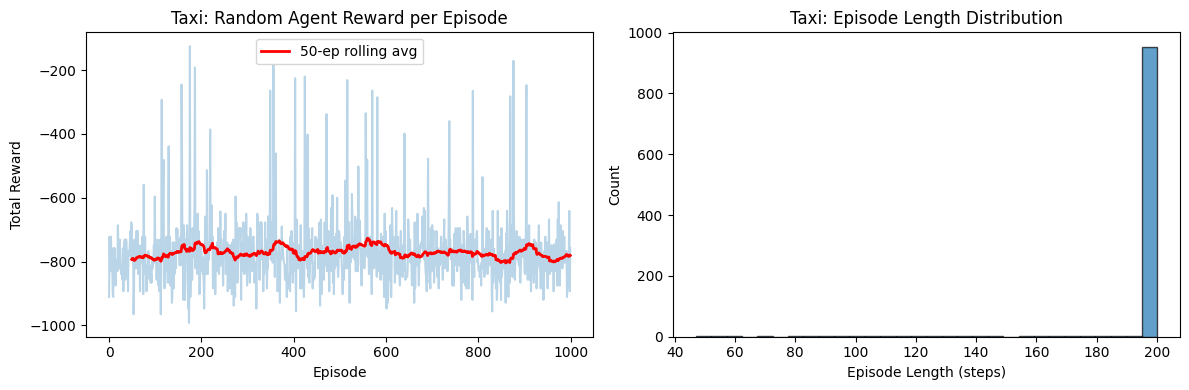

In [35]:
# Plot and save results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(rewards, alpha=0.3)
window = 50
rolling_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
ax1.plot(np.arange(window-1, len(rewards)), rolling_avg, color='red', linewidth=2, label=f'{window}-ep rolling avg')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.set_title('Taxi: Random Agent Reward per Episode')
ax1.legend()

ax2.hist(lengths, bins=30, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Episode Length (steps)')
ax2.set_ylabel('Count')
ax2.set_title('Taxi: Episode Length Distribution')

plt.tight_layout()
fig.savefig('taxi_results.png', dpi=150)
print("Saved taxi_results.png")
plt.show()